## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [3]:
years = range(2023, 2025)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2023 | (38856, 102)
Year: 2024 | (22666, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2023-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.15549,39.67943,2,3,3,2023,1,0.377363,0.463567,-0.367555,-0.463567,0.334882,0.535351,-0.294203,-0.535351,0.135957,0.125207,0.088916,0.125207,4.084839,-1.582903,1.250968,4.084839,-0.418571,2.214516,5.726667,-1.582903,0.141429,0.291935,1.3500,1.250968,-0.138571,1.253226,3.538333,6.876940,91.993599,134.366799,213.185130,213.185130,213.185130,-2.45,14.09,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,10.750000,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.000000,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2023-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.15549,39.67943,2,3,3,2023,2,0.123490,0.730944,-0.133487,-0.730944,0.114791,0.722676,-0.108799,-0.722676,0.112847,0.086158,0.081423,0.086158,-0.418571,0.141429,1.102857,4.084839,-0.418571,2.214516,5.726667,-1.582903,0.141429,0.291935,1.3500,1.250968,-0.138571,1.253226,3.538333,3.515089,68.507632,80.796871,99.198501,311.607632,98.422501,-4.71,3.19,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,10.750000,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.000000,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2023-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.15549,39.67943,2,3,3,2023,3,0.323807,0.327114,-0.320432,-0.327114,0.245422,0.470911,-0.233756,-0.470911,0.164347,0.159382,0.123286,0.159382,2.214516,0.291935,1.253226,4.084839,-0.418571,2.214516,5.726667,-1.582903,0.141429,0.291935,1.3500,1.250968,-0.138571,1.253226,3.538333,2.813795,4.659091,52.631827,85.770852,398.835283,87.227652,-0.35,7.53,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,10.750000,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.000000,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2023-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.15549,39.67943,2,3,3,2023,4,0.446959,0.192068,-0.408253,-0.192068,0.354502,0.241695,-0.314134,-0.241695,0.138111,0.137064,0.104665,0.137064,5.726667,1.350000,3.538333,4.084839,-0.418571,2.214516,5.726667,-1.582903,0.141429,0.291935,1.3500,1.250968,-0.138571,1.253226,3.538333,2.838995,5.948116,35.428835,85.169852,484.005135,85.169852,-0.11,18.71,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,10.750000,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.000000,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

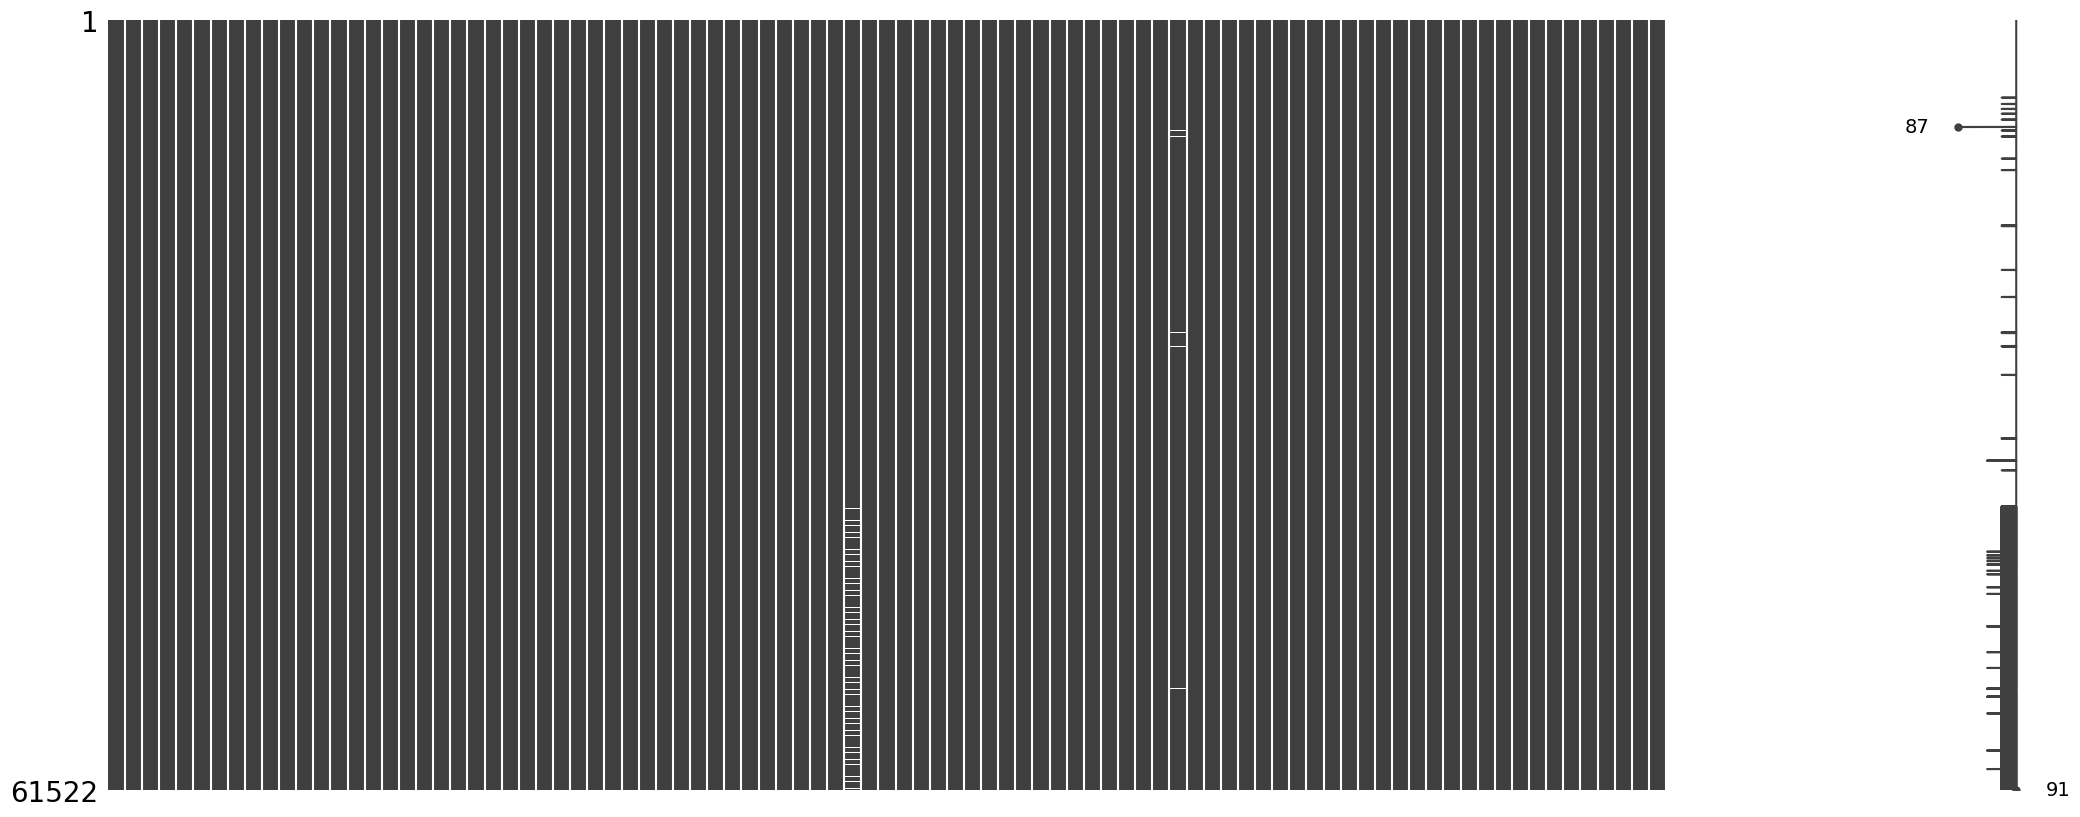

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,0.0016
17,ndmi,0.0016
18,ndwi,0.0016
19,ndbi,0.0016
29,lst_night_mean,0.0033
30,lst_mean,0.0033
43,rainfall_mean,5.2632
62,lc_prop2_assessment,0.7721
91,M_Y_LT15,100.0000
92,M_Y15-64,100.0000


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['NUTS1_ID', 'NUTS1_NAME', 'rainfall_acc']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2023-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,1,2023,0.377363,0.463567,-0.367555,-0.463567,0.334882,0.535351,-0.294203,-0.535351,0.135957,0.125207,0.088916,0.125207,4.084839,4.084839,-0.418571,2.214516,5.726667,-1.582903,-1.582903,0.141429,0.291935,1.3500,1.250968,1.250968,-0.138571,1.253226,3.538333,-2.45,14.09,6.876940,91.993599,134.366799,213.185130,213.185130,10.750000,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.000000,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
1,2023-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,2,2023,0.123490,0.730944,-0.133487,-0.730944,0.114791,0.722676,-0.108799,-0.722676,0.112847,0.086158,0.081423,0.086158,-0.418571,4.084839,-0.418571,2.214516,5.726667,0.141429,-1.582903,0.141429,0.291935,1.3500,1.102857,1.250968,-0.138571,1.253226,3.538333,-4.71,3.19,3.515089,68.507632,80.796871,99.198501,311.607632,10.750000,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.000000,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
2,2023-03,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,3,2023,0.323807,0.327114,-0.320432,-0.327114,0.245422,0.470911,-0.233756,-0.470911,0.164347,0.159382,0.123286,0.159382,2.214516,4.084839,-0.418571,2.214516,5.726667,0.291935,-1.582903,0.141429,0.291935,1.3500,1.253226,1.250968,-0.138571,1.253226,3.538333,-0.35,7.53,2.813795,4.659091,52.631827,85.770852,398.835283,10.750000,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.000000,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
3,2023-04,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,4,2023,0.446959,0.192068,-0.408253,-0.192068,0.354502,0.241695,-0.314134,-0.241695,0.138111,0.137064,0.104665,0.137064,5.726667,4.084839,-0.418571,2.214516,5.726667,1.350000,-1.582903,0.141429,0.291935,1.3500,3.538333,1.250968,-0.138571,1.253226,3.538333,-0.11,18.71,2.838995,5.948116,35.428835,85.169852,484.005135,10.750000,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.000000,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
4,2023-05,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,5,2023,0.556772,0.207562,-0.507885,-0.207562,0.423201,0.174366,-0.369059,-0

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
months = range(1,8)

In [19]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2024 | Month: 1
Year: 2024 | Month: 2
Year: 2024 | Month: 3
Year: 2024 | Month: 4
Year: 2024 | Month: 5
Year: 2024 | Month: 6
Year: 2024 | Month: 7


In [20]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2023-01,"καρδιτσα, τρικαλα",0,21.15549,39.67943,1,2023,0.377363,0.463567,-0.367555,-0.463567,0.334882,0.535351,-0.294203,-0.535351,0.135957,0.125207,0.088916,0.125207,4.084839,4.084839,-0.418571,2.214516,5.726667,-1.582903,-1.582903,0.141429,0.291935,1.35,1.250968,1.250968,-0.138571,1.253226,3.538333,-2.45,14.09,6.876940,91.993599,134.366799,213.185130,213.185130,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
1,2023-02,"καρδιτσα, τρικαλα",0,21.15549,39.67943,2,2023,0.123490,0.730944,-0.133487,-0.730944,0.114791,0.722676,-0.108799,-0.722676,0.112847,0.086158,0.081423,0.086158,-0.418571,4.084839,-0.418571,2.214516,5.726667,0.141429,-1.582903,0.141429,0.291935,1.35,1.102857,1.250968,-0.138571,1.253226,3.538333,-4.71,3.19,3.515089,68.507632,80.796871,99.198501,311.607632,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
2,2023-03,"καρδιτσα, τρικαλα",0,21.15549,39.67943,3,2023,0.323807,0.327114,-0.320432,-0.327114,0.245422,0.470911,-0.233756,-0.470911,0.164347,0.159382,0.123286,0.159382,2.214516,4.084839,-0.418571,2.214516,5.726667,0.291935,-1.582903,0.141429,0.291935,1.35,1.253226,1.250968,-0.138571,1.253226,3.538333,-0.35,7.53,2.813795,4.659091,52.631827,85.770852,398.835283,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
3,2023-04,"καρδιτσα, τρικαλα",0,21.15549,39.67943,4,2023,0.446959,0.192068,-0.408253,-0.192068,0.354502,0.241695,-0.314134,-0.241695,0.138111,0.137064,0.104665,0.137064,5.726667,4.084839,-0.418571,2.214516,5.726667,1.350000,-1.582903,0.141429,0.291935,1.35,3.538333,1.250968,-0.138571,1.253226,3.538333,-0.11,18.71,2.838995,5.948116,35.428835,85.169852,484.005135,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,31,97,30,97.0,30,97,10,10,1,6,6,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
4,2023-05,"καρδιτσα, τρικαλα",0,21.15549,39.67943,5,2023,0.556772,0.207562,-0.507885,-0.207562,0.423201,0.174366,-0.369059,-0.174366,0.099434,0.063119,0.078951,0.063119,18.999032,4.084839,-0.418571,2.214516,5.726667,4.410645,-1.582903,0.141429,0.291935,1.35,11.704839,1.250968,-0.138571,1.253226,3.538333,1.07,19.35,10.256313,162.308075,204.945278,317.205955,801.950838,10.75,17.833333,4

In [21]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2024)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL61,EL611,καλαμπακας,2024,1,21.15549,39.67943,0.519323,0.346931,-0.478636,-0.346931,0.461435,0.414268,-0.393222,-0.414268,0.135164,0.113042,0.095687,0.113042,4.254516,-0.991935,-0.092759,4.69,21.882,0.744839,-0.470645,0.50931,-0.168065,4.6492,2.499677,-0.73129,0.208276,2.260968,13.2656,-0.75,11.35,0.982926,2.080662,3.086945,30.099864,159.973270,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,31,30,30,10,10,1,6,6,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
3238,0,EL61,EL611,καλαμπακας,2024,2,21.15549,39.67943,0.371725,0.442767,-0.361823,-0.442767,0.257971,0.519864,-0.230535,-0.519864,0.137063,0.097580,0.100163,0.097580,-0.991935,-0.991935,-0.092759,4.69,21.882,-0.470645,-0.470645,0.50931,-0.168065,4.6492,-0.731290,-0.73129,0.208276,2.260968,13.2656,-6.51,4.11,5.160428,0.877919,33.839919,158.808756,230.869789,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,31,30,30,10,10,1,6,6,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
6476,0,EL61,EL611,καλαμπακας,2024,3,21.15549,39.67943,0.382497,0.308098,-0.371832,-0.308098,0.316973,0.414177,-0.290961,-0.414177,0.144727,0.110431,0.107920,0.110431,-0.092759,-0.991935,-0.092759,4.69,21.882,0.509310,-0.470645,0.50931,-0.168065,4.6492,0.208276,-0.73129,0.208276,2.260968,13.2656,-6.51,3.47,2.444708,45.889599,45.918399,70.896519,351.790460,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,31,30,30,10,10,1,6,6,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
9714,0,EL61,EL611,καλαμπακας,2024,4,21.15549,39.67943,0.396450,0.328166,-0.388651,-0.328166,0.360011,0.320641,-0.337045,-0.320641,0.112808,0.113910,0.076133,0.113910,4.690000,-0.991935,-0.092759,4.69,21.882,-0.168065,-0.470645,0.50931,-0.168065,4.6492,2.260968,-0.73129,0.208276,2.260968,13.2656,-5.15,20.79,4.030689,10.146586,21.433531,112.105071,445.826719,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,31,30,30,10,10,1,6,6,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3
12952,0,EL61,EL611,καλαμπακας,2024,5,21.15549,39.67943,0.494387,0.275380,-0.457889,-0.275380,0.469462,0.259850,-0.428911,-0.259850,0.084973,0.113481,0.051440,0.113481,21.882000,-0.991935,-0.092759,4.69,21.882,4.649200,-0.470645,0.50931,-0.168065,4.6492,13.265600,-0.73129,0.208276,2.260968,13.2656,0.39,26.57,3.242630,9.256397,85.725295,94.036259,493.906614,10.75,17.833333,44.583333,725.978963,35.0,-5.0,40.0,11.833333,4.0,20.166667,3.0,1791.0,317.0,30.0,65.582431,677.0,270.0,380.0,398.0,31,30,30,10

<Axes: >

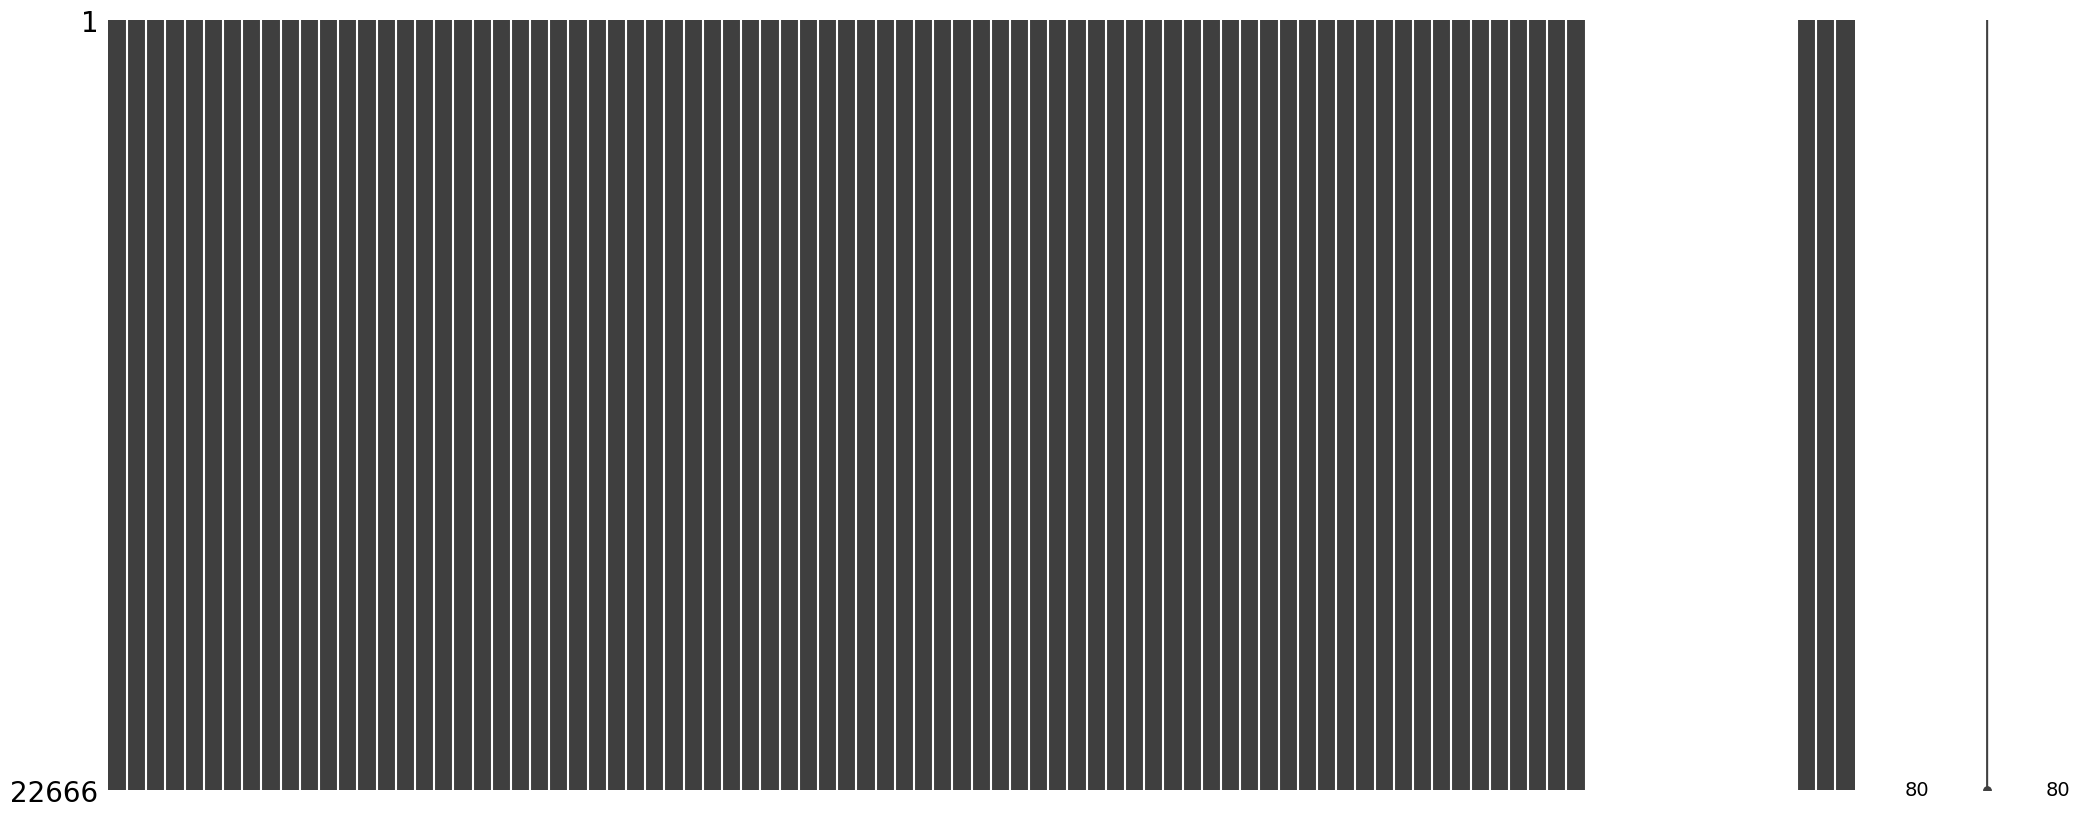

In [22]:
missingno.matrix(dataset_operational)

In [23]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
77,males_lt15,100.0
78,males_15t64,100.0
79,males_gt65,100.0
80,males_total,100.0
81,females_lt15,100.0
82,females_15t64,100.0
83,females_gt65,100.0
84,females_total,100.0
85,mio_eur,100.0
86,l_total,100.0


In [24]:
# dataset_monthly.cases.sum()

In [25]:
# dataset_operational.cases.sum()

In [26]:
years = dataset_operational.year.unique().tolist()

In [27]:
years

[2024]

In [28]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)